<a href="https://colab.research.google.com/github/amit-devs/ecommerce-recommendation-system-2/blob/main/Content_Based_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Content Based**

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/ml_tae/cleaned_products.csv"
df = pd.read_csv(path)

df.head()


,user_id,product_id,rating,product_name,brand_name,about_item,product_description,breadcrumbs,combined_text,weighted_rating
0,R199C1DG57O8P6,B07FMX9FSF,5.0,POLO RALPH LAUREN Men's Slim Fit Cotton Crew U...,POLO Store,"Length: 29.25in / 74cm, Chest: 41in / 104cm",POLO mens Polo Ralph Lauren Slim Fit Wicking C...,"Clothing, Shoes & Jewelry › Men › Clothing › U...",polo ralph lauren men's slim fit cotton crew u...,4.788114
1,R1UFTLDMUCDF0W,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
2,R12009XIWF7S1B,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
3,R30F5N17APS8XF,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
4,R3M1U8JP4SQ93K,B07FMZ31SR,4.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.288114


In [5]:
df.info()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2322 entries, 0 to 2321
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2322 non-null   object 
 1   product_id           2322 non-null   object 
 2   rating               2322 non-null   float64
 3   product_name         2322 non-null   object 
 4   brand_name           2322 non-null   object 
 5   about_item           2322 non-null   object 
 6   product_description  2322 non-null   object 
 7   breadcrumbs          2322 non-null   object 
 8   combined_text        2322 non-null   object 
 9   weighted_rating      2322 non-null   float64
dtypes: float64(2), object(8)
memory usage: 181.5+ KB


Index(['user_id', 'product_id', 'rating', 'product_name', 'brand_name',
       'about_item', 'product_description', 'breadcrumbs', 'combined_text',
       'weighted_rating'],
      dtype='object')

In [6]:
df = df.dropna()

# Convert to product-level dataset
df_products = (
    df.sort_values("weighted_rating", ascending=False)
    .drop_duplicates(subset="product_name")
    .reset_index(drop=True)
)

df_products.head()

,user_id,product_id,rating,product_name,brand_name,about_item,product_description,breadcrumbs,combined_text,weighted_rating
0,RZ1LVZ6QUGPMT,B07BN24BLX,5.0,Nautica Men's Short Sleeve Solid Stretch Cotto...,Nautica Store,Casual styling and a stretch pique fabrication...,A contrasting collar keeps things interesting ...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",nautica men's short sleeve solid stretch cotto...,4.788114
1,R199C1DG57O8P6,B07FMX9FSF,5.0,POLO RALPH LAUREN Men's Slim Fit Cotton Crew U...,POLO Store,"Length: 29.25in / 74cm, Chest: 41in / 104cm",POLO mens Polo Ralph Lauren Slim Fit Wicking C...,"Clothing, Shoes & Jewelry › Men › Clothing › U...",polo ralph lauren men's slim fit cotton crew u...,4.788114
2,R1D8C234SCBITT,B016Y8268U,5.0,Lee Men's Extreme Motion Flat Front Short,Lee Store,STRAIGHT FIT. With a straight fit from the sea...,"Just like our founder, H.D. Lee, our passion i...","Clothing, Shoes & Jewelry › Men › Clothing › S...",lee men's extreme motion flat front short lee ...,4.788114
3,R1W024Q6V3RME1,B00XKYM2AE,5.0,Wrangler Authentics Men's Premium Twill Cargo ...,Wrangler Authentics Store,RELAXED FIT. These cargo shorts sit at the nat...,Wrangler Authentics Men's Premium Relaxed Fit ...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",wrangler authentics men's premium twill cargo ...,4.788114
4,RQ4U957SAA16E,B00BBW2XZG,5.0,Dockers Men's Perfect Classic Fit Shorts (Regu...,DOCKERS Store,Classic fit - Our classic fit is what we built...,Cleverly crafted in a range of timeless and bo...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",dockers men's perfect classic fit shorts (regu...,4.788114


In [7]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(df_products['combined_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (250, 3018)


In [8]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [10]:
indices = pd.Series(df_products.index, index=df_products['product_name']).drop_duplicates()

def recommend_products(product_name, top_n=5):

    product_name = product_name.lower()

    matches = df_products[
        df_products['product_name'].str.lower().str.contains(product_name)
    ]

    if matches.empty:
        print("Product not found in dataset")
        return None

    idx = matches['weighted_rating'].idxmax()

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    product_indices = [i[0] for i in sim_scores]

    return df_products[['product_name','brand_name','weighted_rating']].iloc[product_indices]

In [12]:
product = input("Enter product name: ")

results = recommend_products(product,5)

print("\nRecommended Products:\n")

print(results)

Enter product name: shirt

Recommended Products:

                                          product_name             brand_name  \
10   U.S. Polo Assn. Men's Classic Polo Shirt, Two-...  U.S. Polo Assn. Store   
25   Nautica Men's Solid Crew Neck Short-Sleeve Poc...          Nautica Store   
30   Nautica Men's Short Sleeve Solid Crew Neck T-S...          Nautica Store   
226            Nautica Men's Cotton Woven 3 Pack Boxer          Nautica Store   
21   Nautica Men's Classic Fit Short Sleeve Dual Ti...          Nautica Store   

     weighted_rating  
10          4.788114  
25          4.788114  
30          4.788114  
226         4.788114  
21          4.788114  


In [14]:
merged = results.merge(
    df[['product_name','rating']],
    on="product_name",
    how="left"
)

merged["actual"] = merged["rating"].apply(lambda x: 1 if x>=4 else 0)

merged["predicted"] = 1

y_true = merged["actual"]
y_pred = merged["predicted"]

accuracy = accuracy_score(y_true,y_pred)*100
precision = precision_score(y_true,y_pred,zero_division=0)
recall = recall_score(y_true,y_pred,zero_division=0)
f1 = f1_score(y_true,y_pred,zero_division=0)

print("\nModel Evaluation")

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

print("\nConfusion Matrix")

print(confusion_matrix(y_true,y_pred))


Model Evaluation
Accuracy: 86.66666666666667
Precision: 0.8666666666666667
Recall: 1.0
F1 Score: 0.9285714285714286

Confusion Matrix
[[ 0  6]
 [ 0 39]]


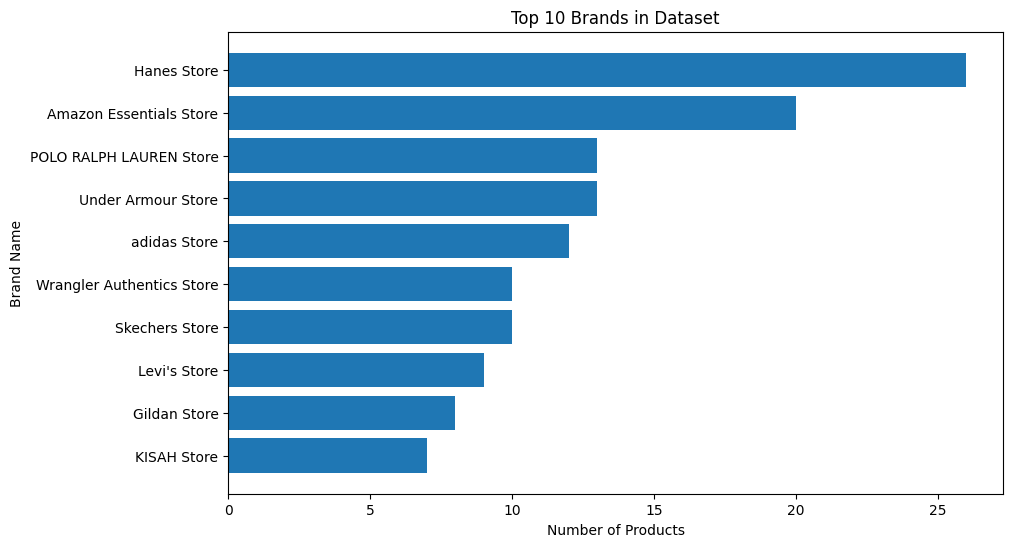

In [22]:
top_brands = df_products['brand_name'].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.barh(top_brands.index, top_brands.values)

plt.title("Top 10 Brands in Dataset")

plt.xlabel("Number of Products")

plt.ylabel("Brand Name")

plt.gca().invert_yaxis()

plt.show()

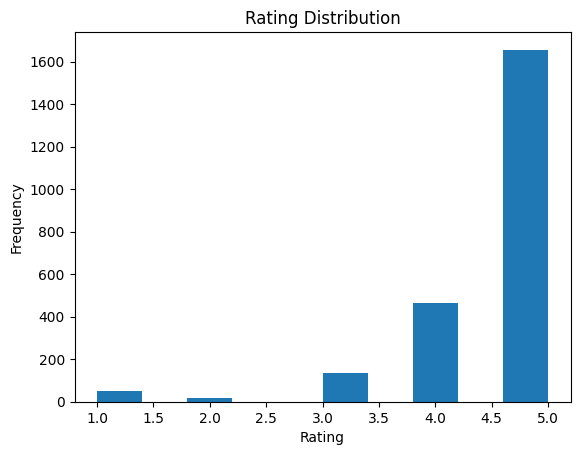

In [18]:
plt.hist(df['rating'], bins=10)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

In [ ]:
def search_product(keyword):

    # First search only in product name
    results = df[df['product_name'].str.contains(keyword, case=False)]

    # remove duplicate products
    results = results.drop_duplicates(subset='product_name')

    # sort by rating
    results = results.sort_values(by="rating", ascending=False)

    return results[['product_name','brand_name','rating']].head(5).reset_index(drop=True)

In [ ]:
keyword = input("Enter product keyword (example: jeans, shirt, shoes): ")

print("\nTop 5 Recommended Products:\n")

results = search_product(keyword)

print(results)

Enter product keyword (example: jeans, shirt, shoes): jeans

Top 5 Recommended Products:

                                                  product_name  \
0  Levi Strauss Signature Gold Men's Relaxed Fit Flex Jeans...   
1             Levi Strauss Signature Gold Men's Slim Fit Jeans   
2                     Amazon Essentials Slim Fit Jeans For Men   
3            Levi Strauss Signature Gold Men's Carpenter Jeans   
4          Signature by Levi Strauss & Co Men's Fit Flex Jeans   

                          brand_name  rating  
0  Levi Strauss Signature Gold Store     5.0  
1  Levi Strauss Signature Gold Store     5.0  
2            Amazon Essentials Store     5.0  
3  Levi Strauss Signature Gold Store     5.0  
4  Levi Strauss Signature Gold Store     5.0  


In [ ]:
def recommend_products(product_name, top_n=5):

    if product_name not in indices:
        print("Product not found in dataset")
        return

    idx = indices[product_name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # take more results first to remove duplicates later
    sim_scores = sim_scores[1:50]

    product_indices = [i[0] for i in sim_scores]

    results = df[['product_name','brand_name','rating']].iloc[product_indices]

    # remove duplicate products
    results = results.drop_duplicates(subset='product_name')

    return results.head(top_n)

In [ ]:
sample_product = df['product_name'].iloc[0]

print("\nProducts similar to:", sample_product)

print(recommend_products(sample_product))


Products similar to: POLO RALPH LAUREN Men's Slim Fit Cotton Crew Undershirts, 3 Pack
                                                    product_name  \
52   Polo Ralph Lauren Men's Slim Fit Cotton V-neck Undershir...   
1    POLO RALPH LAUREN Men's Classic Fit Cotton V-Neck Unders...   
119      POLO RALPH LAUREN Men's Classic Fit Cotton Tanks 3-pack   
11   POLO RALPH LAUREN Slim Fit Undershirt w/Wicking 5-Pack C...   
32    POLO RALPH LAUREN Boys' Multi-Pack Short Sleeve Undershirt   

                  brand_name  rating  
52   POLO RALPH LAUREN Store     5.0  
1                 POLO Store     5.0  
119  POLO RALPH LAUREN Store     5.0  
11   POLO RALPH LAUREN Store     5.0  
32   POLO RALPH LAUREN Store     5.0  


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# True ratings
y_true = df['rating']

# Predicted ratings (using weighted rating column from dataset)
y_pred = df['weighted_rating']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Model Accuracy Metric (RMSE):", rmse)

Model Accuracy Metric (RMSE): 0.4060014563945908


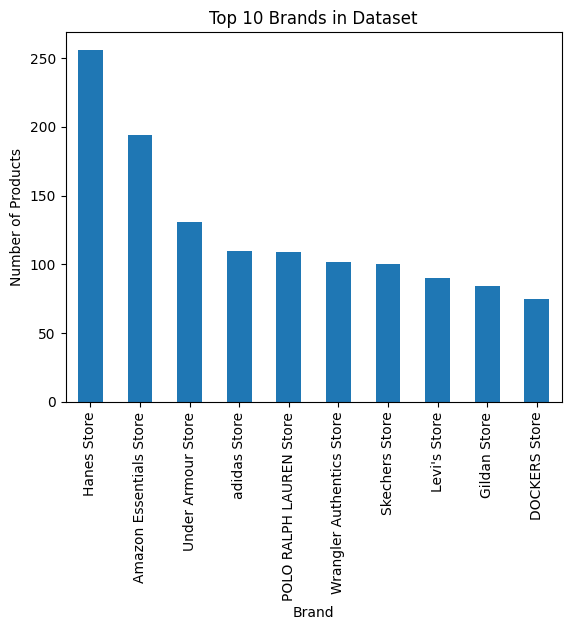

In [ ]:
import matplotlib.pyplot as plt

top_brands = df['brand_name'].value_counts().head(10)

top_brands.plot(kind='bar')

plt.title("Top 10 Brands in Dataset")

plt.xlabel("Brand")

plt.ylabel("Number of Products")

plt.show()

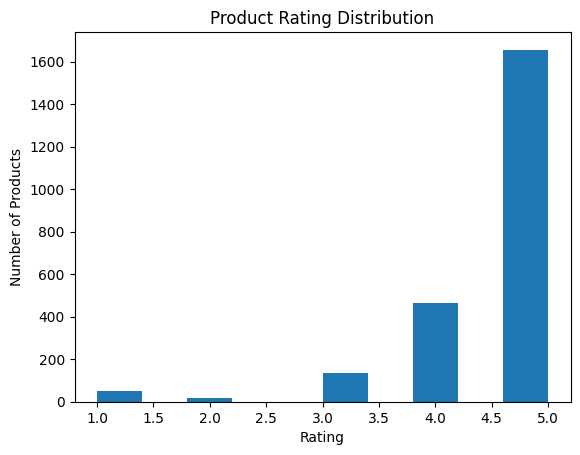

In [ ]:
plt.hist(df['rating'], bins=10)

plt.title("Product Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Number of Products")

plt.show()